In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [49]:
import arviz as az
import gp_model
from hls import HarmonicLombScargle
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

sns.set_theme(context='notebook', style='ticks', palette='colorblind')

In [3]:
search_result = lk.search_lightcurve('KIC 5111207')
lcs = [sr.download() for sr in tqdm(search_result)]

100%|██████████| 14/14 [00:00<00:00, 20.11it/s]


I am going to sigma-clip the fluxes of the light curve and add those points to the mask (the outliers make the GP fit particularly poor, I think).

In [4]:
lcs = [lc.remove_outliers() for lc in lcs]

In [5]:
times = [lc.time.value for lc in lcs]
fluxes = [lc.flux.value for lc in lcs]
flux_errs = [lc.flux_err.value for lc in lcs]
masks = [~f.mask for f in fluxes]

times = [t[m] for t, m in zip(times, masks)]
fluxes = [f[m] for f, m in zip(fluxes, masks)]
flux_errs = [f[m] for f, m in zip(flux_errs, masks)]

quarters = [float(i)*np.ones_like(t) for (i, t) in enumerate(times)]

times = np.concatenate(times).astype(np.float64)
fluxes = np.array(np.concatenate(fluxes).astype(np.float64))
flux_errs = np.array(np.concatenate(flux_errs).astype(np.float64))
quarters = np.concatenate(quarters)

uquarters, quarter_indices = np.unique(quarters, return_inverse=True)

In [6]:
hls = HarmonicLombScargle(times, fluxes, quarters, 1) # I sorta only trust the model for one harmonic

In [134]:
fgrid = hls.relative_frequency_grid(0.05)
fgrid = fgrid[fgrid > 1e-2]
logls = hls.logl_on_grid(fgrid)
power = hls.best_fit_power_estimate_on_grid(fgrid)

  0%|          | 0/160 [00:00<?, ?it/s]/Users/wfarr/Code/harmonic-lomb-scargle/hls.py:57: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x, (rss,), _, _ = np.linalg.lstsq(M, self.flux)
100%|██████████| 160/160 [00:01<00:00, 102.92it/s]


Text(0.5, 0, '$f / \\mathrm{d}^{-1}$')

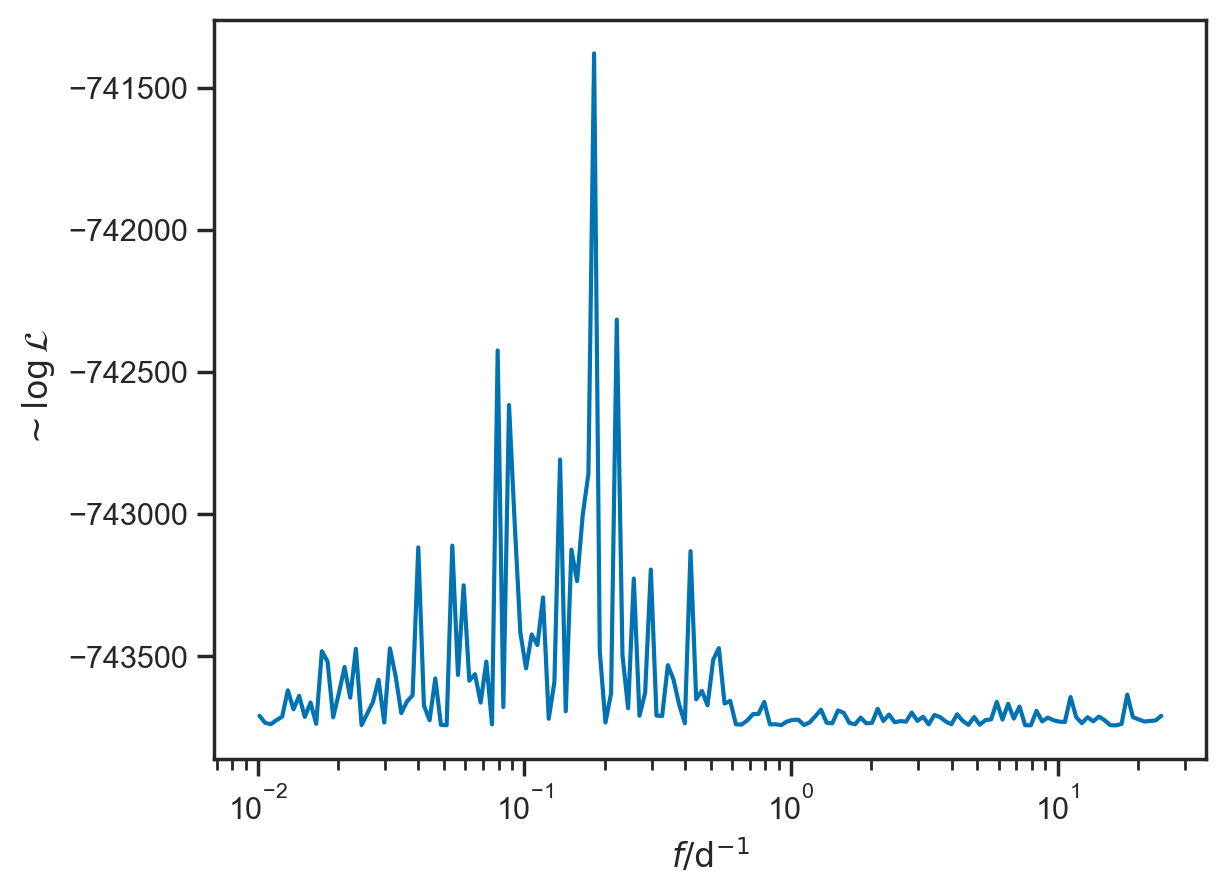

In [135]:
plt.plot(fgrid, logls)
plt.xscale('log')
plt.ylabel(r'$\sim \log\mathcal{L}$')
plt.xlabel(r'$f / \mathrm{d}^{-1}$')

Text(0, 0.5, 'LS Power $\\left( e^- \\right)^2 \\, \\mathrm{s}^{-2}$')

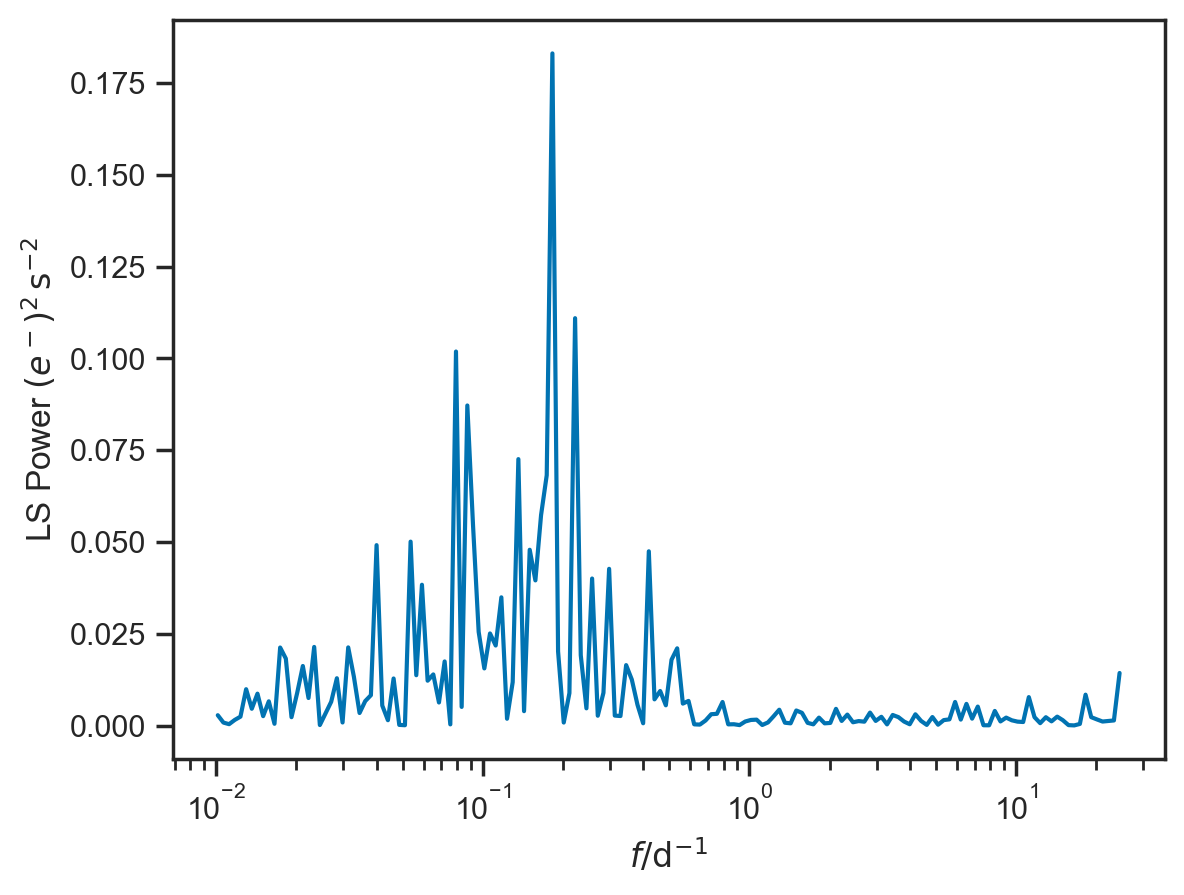

In [136]:
plt.plot(fgrid, power)
plt.xscale('log')
plt.xlabel('$f / \mathrm{d}^{-1}$')
plt.ylabel(r'LS Power $\left( e^- \right)^2 \, \mathrm{s}^{-2}$')

  0%|          | 0/160 [00:00<?, ?it/s]/Users/wfarr/Code/harmonic-lomb-scargle/hls.py:57: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x, (rss,), _, _ = np.linalg.lstsq(M, self.flux)
100%|██████████| 160/160 [00:02<00:00, 60.22it/s]


(1, 100)

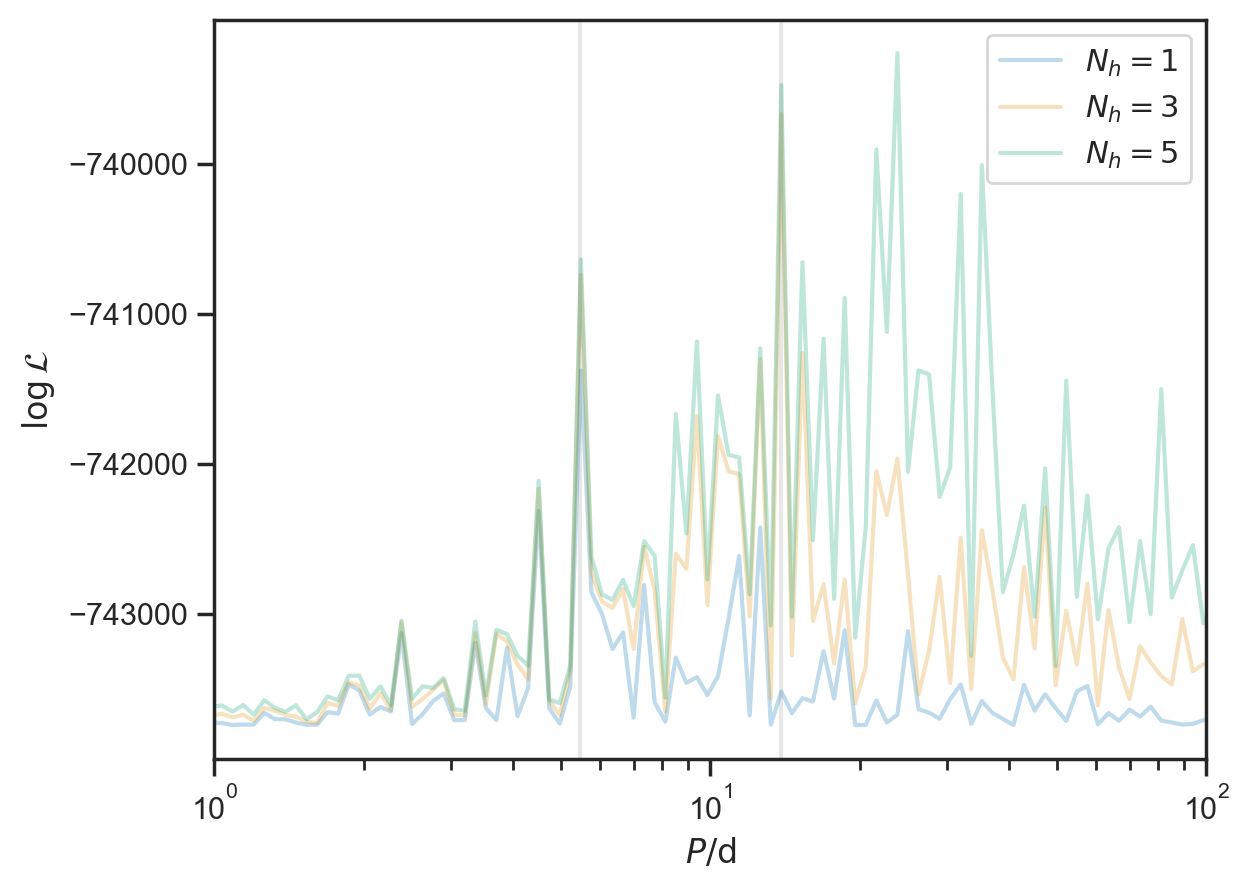

In [138]:
for nh in [1, 3, 5]:
    h = HarmonicLombScargle(times, fluxes, quarters, nh)
    ll = h.logl_on_grid(fgrid)
    plt.plot(1/fgrid, ll, label=r'$N_h = {:d}$'.format(nh), alpha=0.25)
plt.xscale('log')
plt.xlabel(r'$P / \mathrm{d}$')
plt.ylabel(r'$\log \mathcal{L}$')
plt.legend()
plt.axvline(5.47, color='k', alpha=0.1)
plt.axvline(13.91, color='k', alpha=0.1)
plt.xlim(1, 100)

In [110]:
f_guess = fgrid[np.argmax(logls)]

fgrid_fine = hls.fine_frequency_grid(f_guess, 128)
logls_fine = hls.logl_on_grid(fgrid_fine)

  0%|          | 0/128 [00:00<?, ?it/s]/Users/wfarr/Code/harmonic-lomb-scargle/hls.py:57: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x, (rss,), _, _ = np.linalg.lstsq(M, self.flux)
100%|██████████| 128/128 [00:01<00:00, 98.25it/s]


In [115]:
f_best = hls.interpolated_best_frequency(fgrid_fine, logls_fine)
x_best = hls.best_fit_params(f_best)

print(f'f_best = {f_best}/day, or P = {1/f_best} days')

f_best = 0.18258079657038595/day, or P = 5.4770272601724255 days


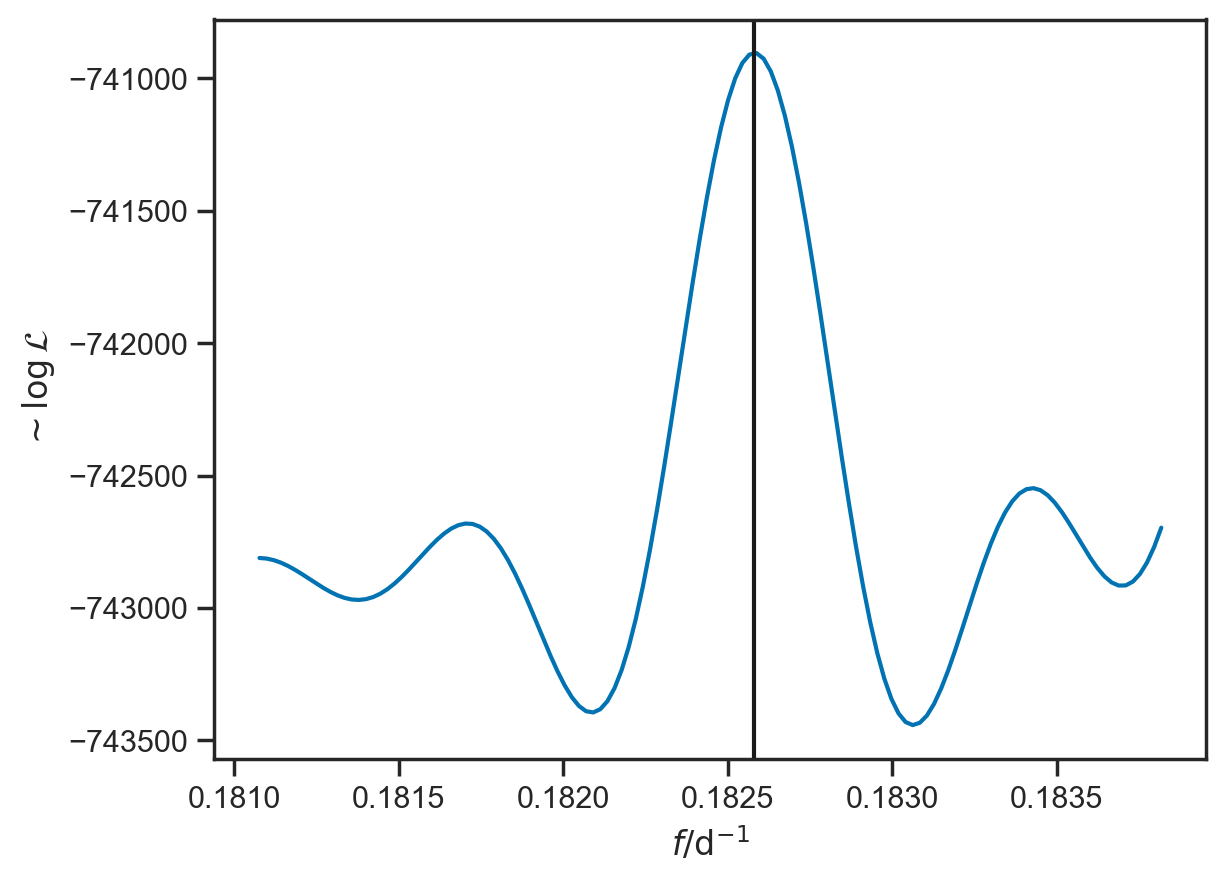

In [116]:
plt.plot(fgrid_fine, logls_fine)
plt.xlabel(r'$f / \mathrm{d}^{-1}$')
plt.ylabel(r'$\sim \log\mathcal{L}$')
plt.axvline(f_best, color='k')

In [117]:
f_best_literature = 1/5.47

/Users/wfarr/Code/harmonic-lomb-scargle/hls.py:57: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x, (rss,), _, _ = np.linalg.lstsq(M, self.flux)


Text(0, 0.5, 'Residuals [e- / s]')

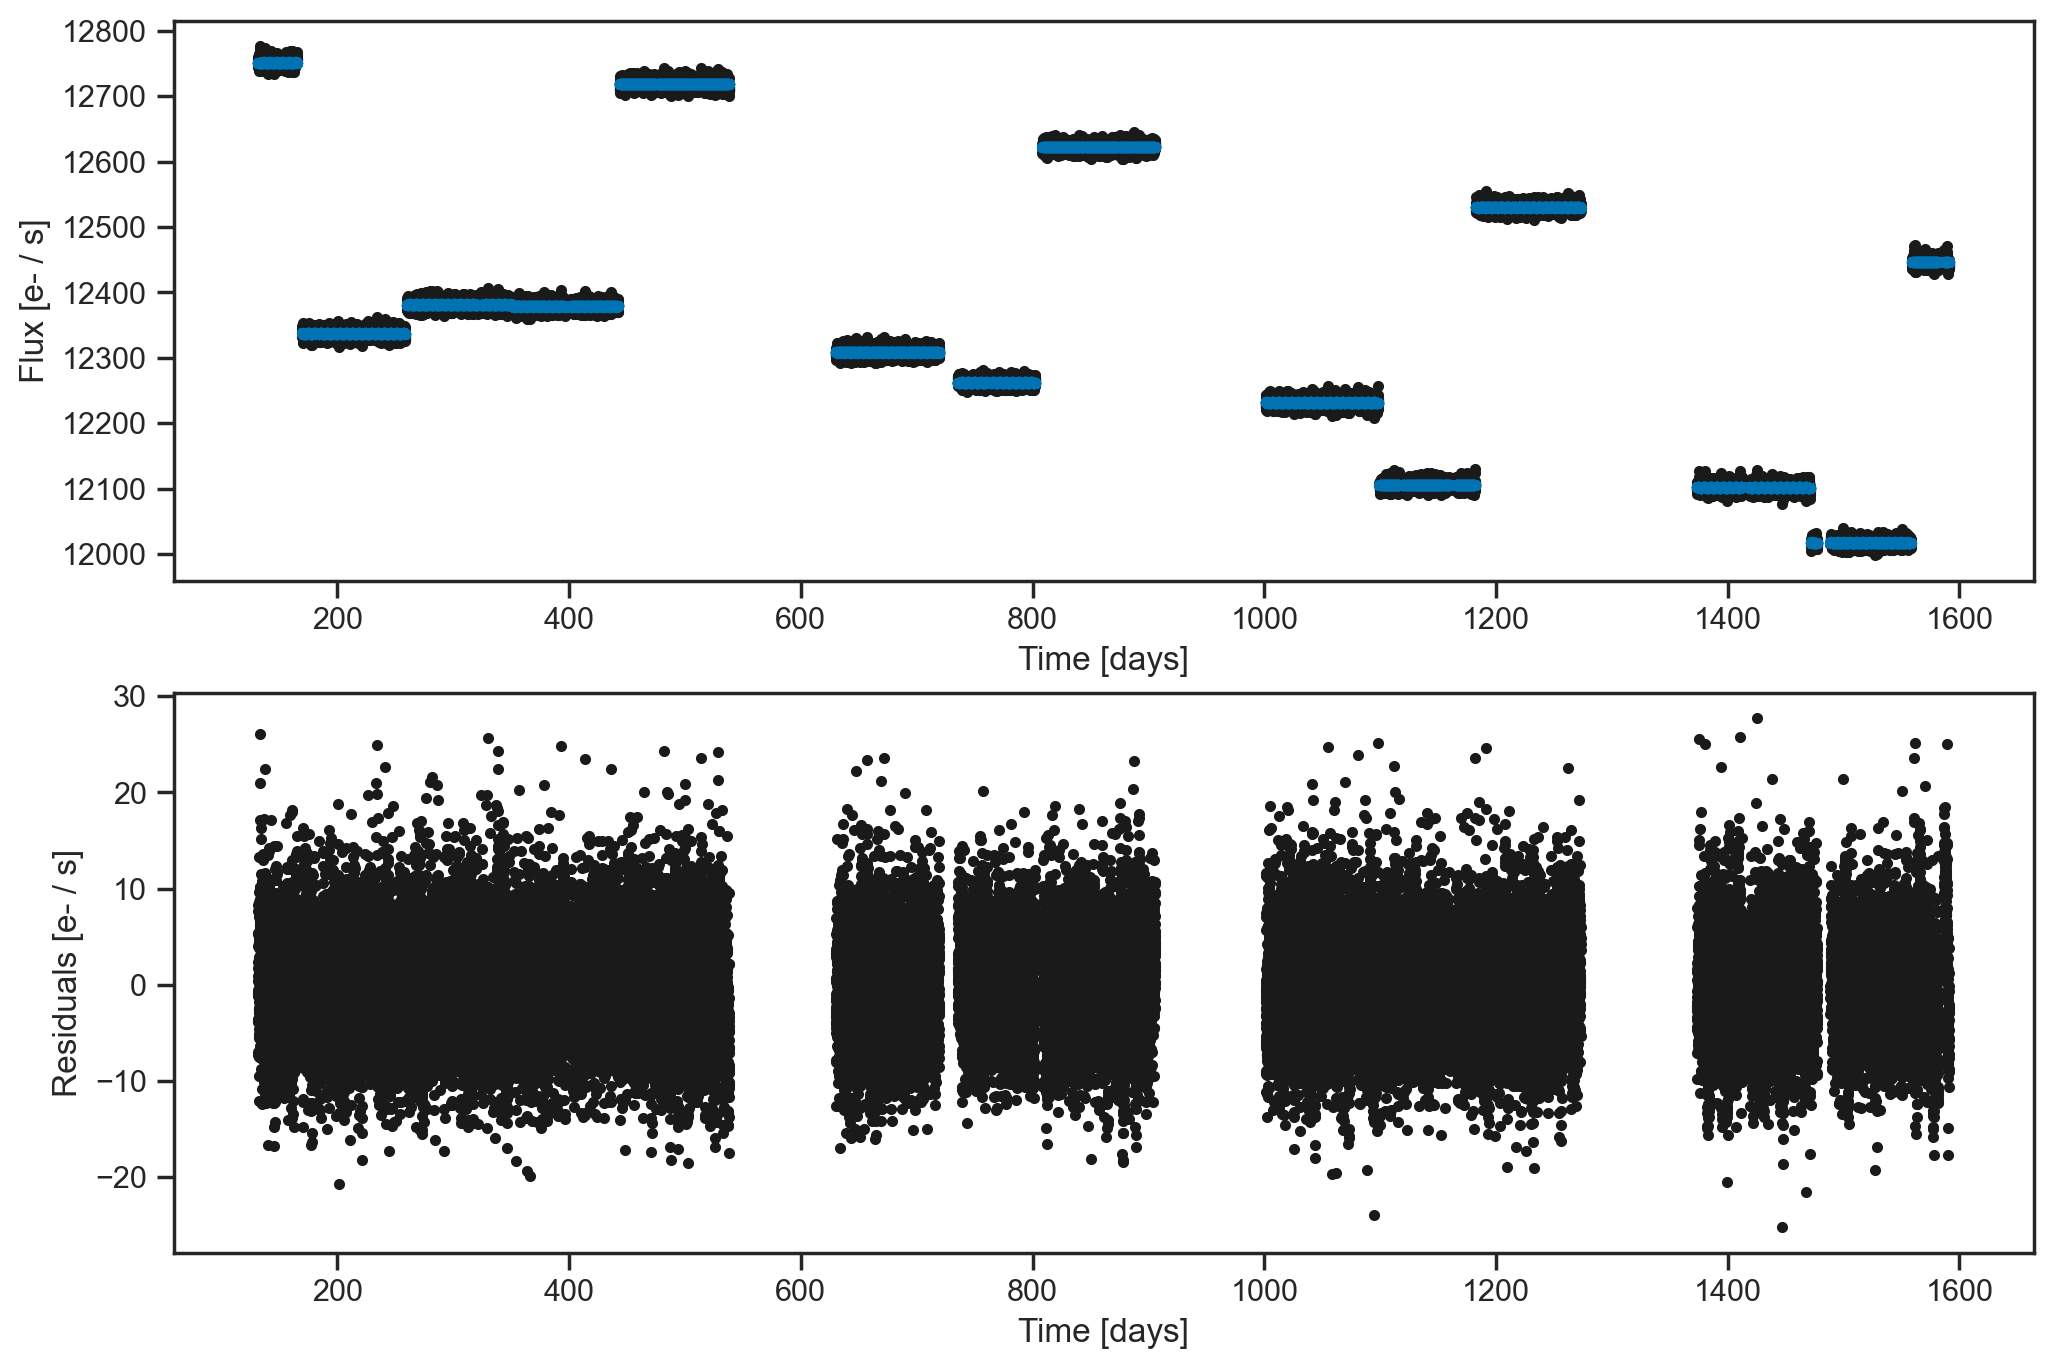

In [118]:
y = hls.predict_flux(f_best)

fig, subplots = plt.subplots(2, 1, figsize=(12, 8))

subplots[0].plot(times, fluxes, '.k')
subplots[0].plot(times, y, '.')
subplots[0].set_xlabel('Time [days]')
subplots[0].set_ylabel('Flux [e- / s]')

subplots[1].plot(times, fluxes - y, '.k')
subplots[1].set_xlabel('Time [days]')
subplots[1].set_ylabel('Residuals [e- / s]')

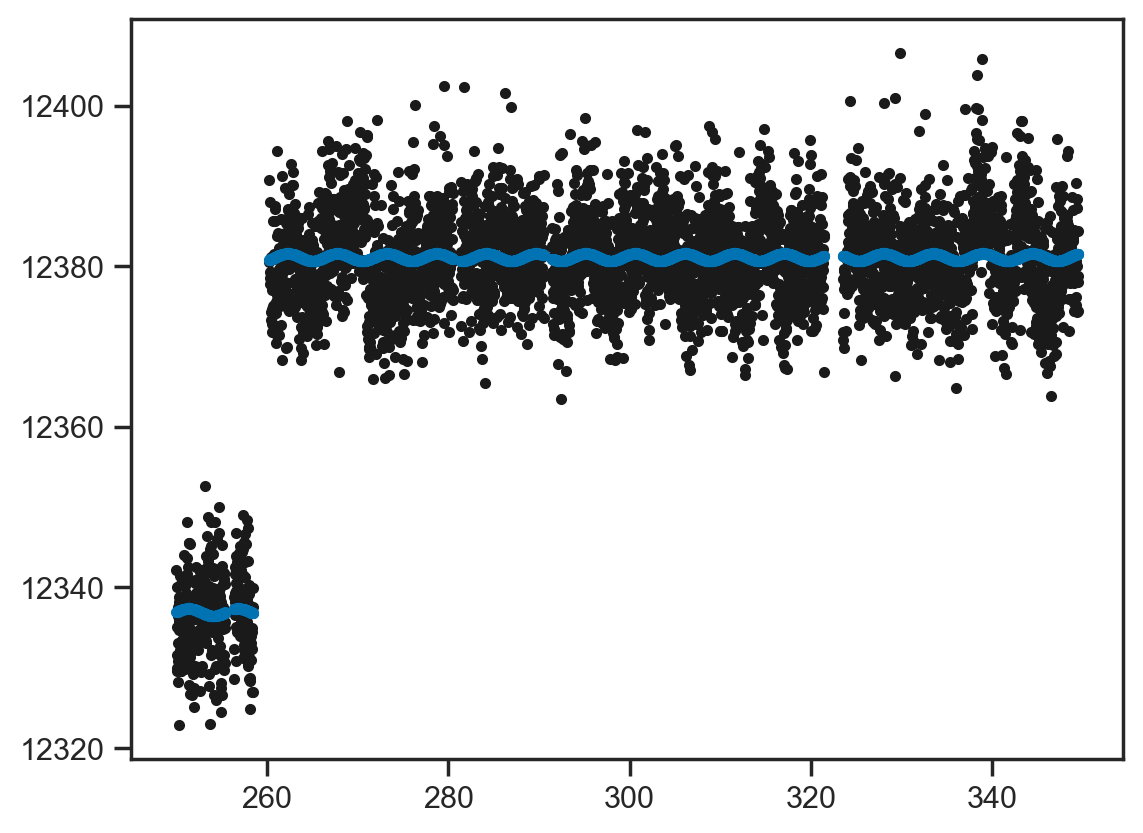

In [16]:
sel = np.abs(times - 300) < 50
plt.plot(times[sel], fluxes[sel], '.k')
plt.plot(times[sel], y[sel], '.')

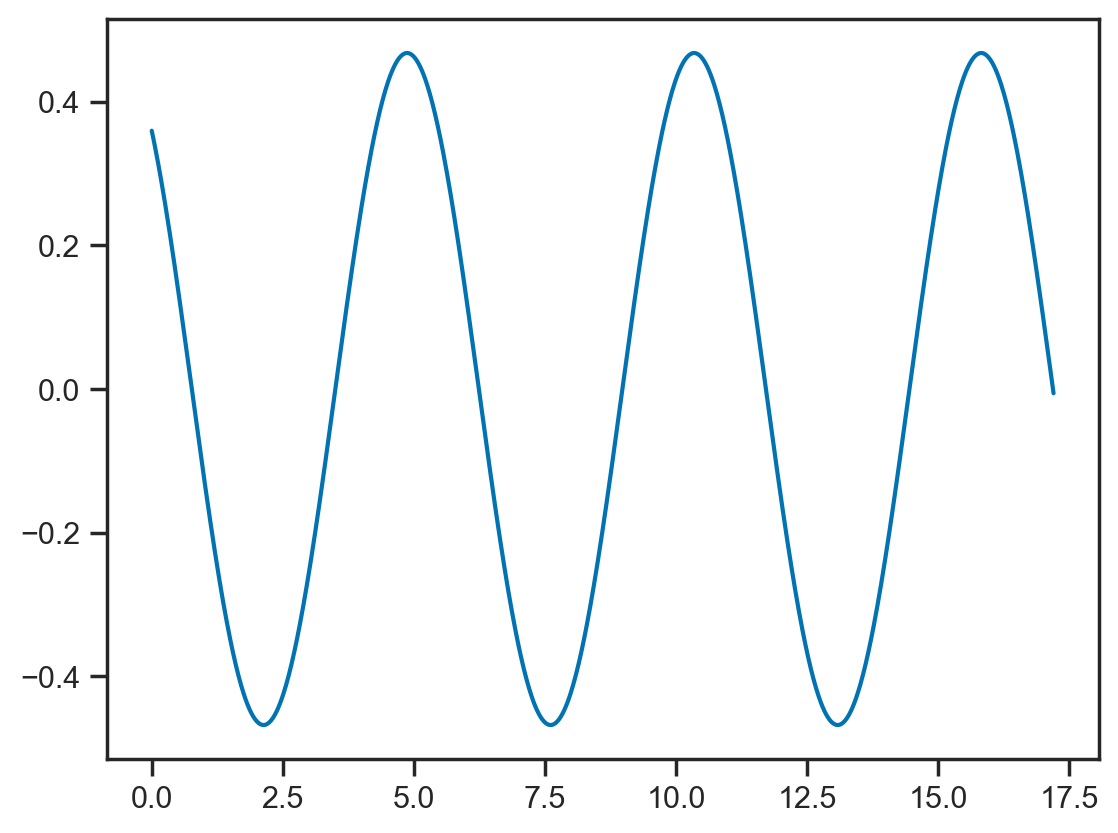

In [17]:
ts = np.linspace(0, np.pi*1/f_best, 1000)
plt.plot(ts, hls.periodic_lightcurve(ts, f_best, x_best))

Now let's try fitting some GP models.

In [18]:
n_in_quarters = np.bincount(quarter_indices)
quarter_means = np.bincount(quarter_indices, weights=fluxes) / n_in_quarters
quarter_vars = np.bincount(quarter_indices, weights=(fluxes - quarter_means[quarter_indices])**2) / n_in_quarters
quarter_stds = np.sqrt(quarter_vars)

total_var = np.sum(quarter_vars * n_in_quarters) / np.sum(n_in_quarters)
total_std = np.sqrt(total_var)

In [19]:
white_noise_variance = np.sum(flux_errs**2) / len(flux_errs)

In [ ]:
dt = np.median(np.diff(times))
fny = 0.5 / dt
T = times[-1] - times[0]
df = 1/T

frequencies = np.arange(df, fny, df)

In [55]:
from importlib import reload
import gp_model
reload(gp_model)

<module 'gp_model' from '/Users/wfarr/Code/harmonic-lomb-scargle/gp_model.py'>

In [103]:
thin_data = 1
model = gp_model.harmonic_sho_model(times[::thin_data], fluxes[::thin_data], flux_errs[::thin_data], quarters[::thin_data], f_best, 0.1, quarter_means, quarter_stds, total_std, psd_freq=frequencies, predict_flux=True)

In [104]:
trace = pm.sample(tune=1000, draws=1000, cores=4, chains=4, model=model, progressbar=True, jitter_max_retries=100, init='adapt_full')

Initializing NUTS using adapt_full...
/Users/wfarr/miniconda3/envs/harmonic-lomb-scargle/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mus_scaled, log_err_scale, log_period_scaled, log_sigma_scaled, frac, dQ1, dQb]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 344 seconds.


array([[<Axes: title={'center': 'mus_scaled'}>,
        <Axes: title={'center': 'mus_scaled'}>],
       [<Axes: title={'center': 'period'}>,
        <Axes: title={'center': 'period'}>],
       [<Axes: title={'center': 'f0'}>, <Axes: title={'center': 'f0'}>],
       [<Axes: title={'center': 'Q0'}>, <Axes: title={'center': 'Q0'}>],
       [<Axes: title={'center': 'Q1'}>, <Axes: title={'center': 'Q1'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'frac'}>,
        <Axes: title={'center': 'frac'}>],
       [<Axes: title={'center': 'err_scale'}>,
        <Axes: title={'center': 'err_scale'}>]], dtype=object)

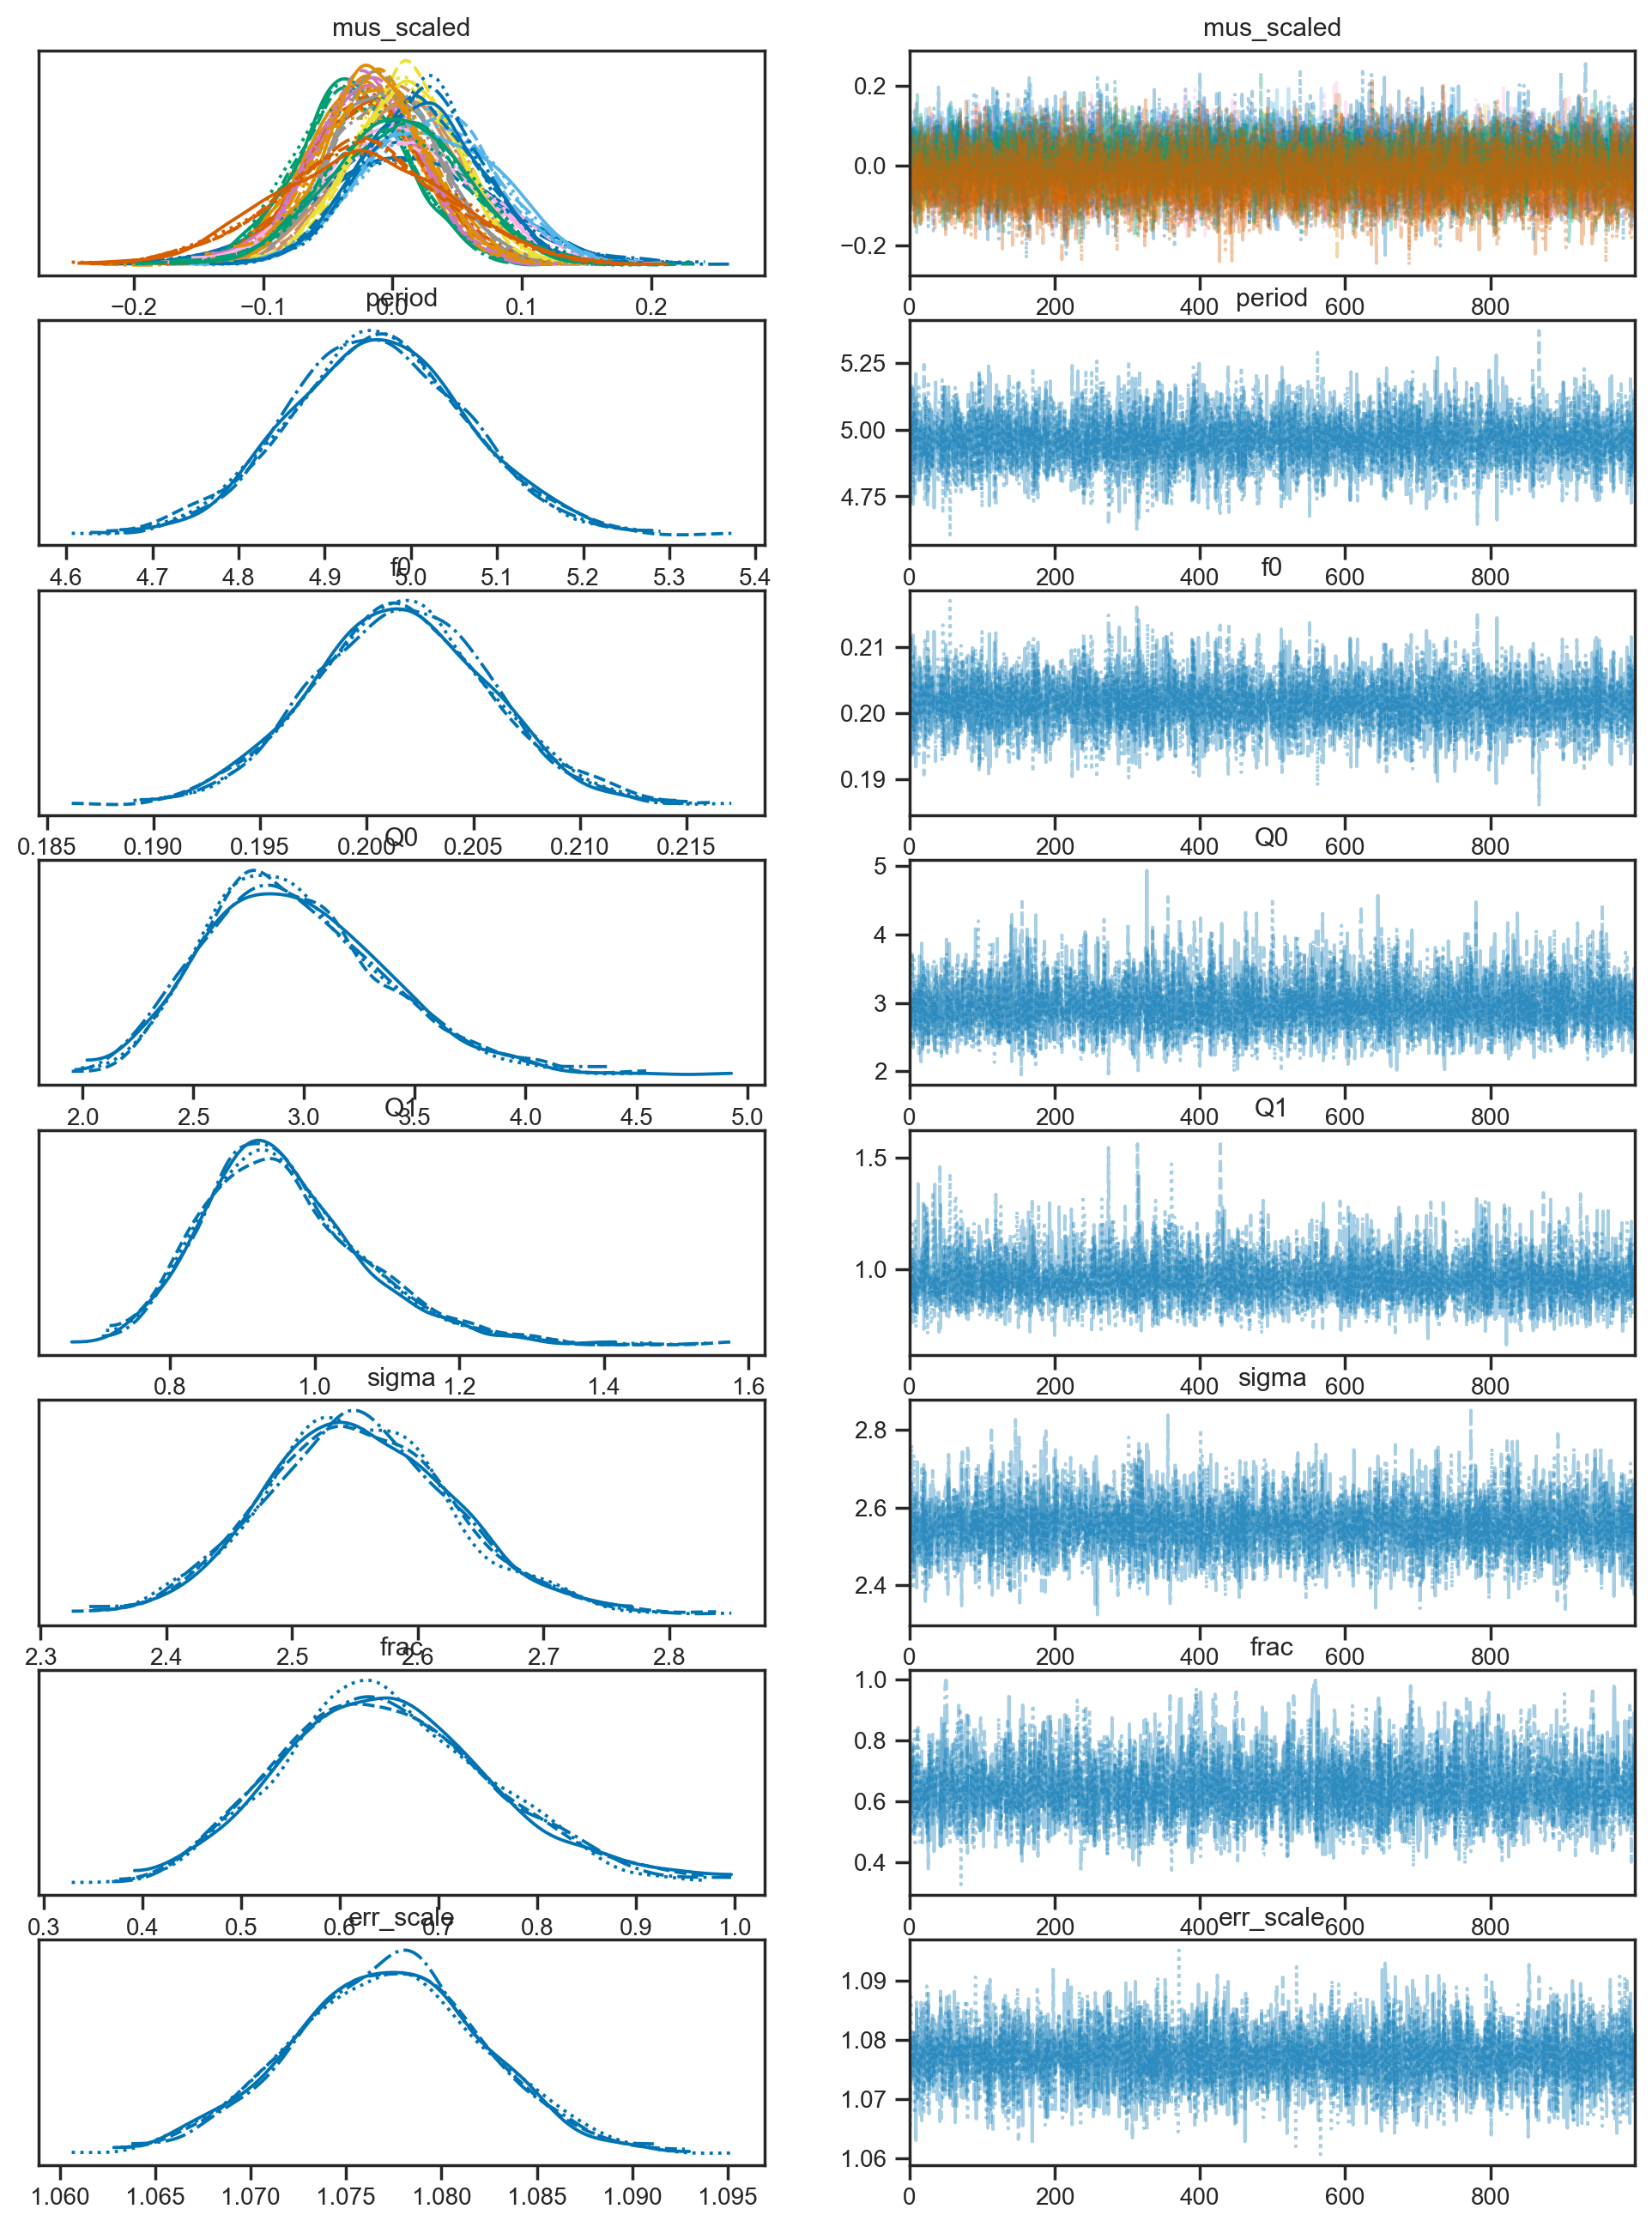

In [96]:
az.plot_trace(trace, var_names=['mus_scaled', 'period', 'f0', 'Q0', 'Q1', 'sigma', 'frac', 'err_scale'])

In [121]:
fm

array([12751.26029731, 12751.29828041, 12751.33521165, ...,
       12442.37866281, 12442.4523517 , 12442.52722615])

Text(0, 0.5, 'Residuals [e- / s]')

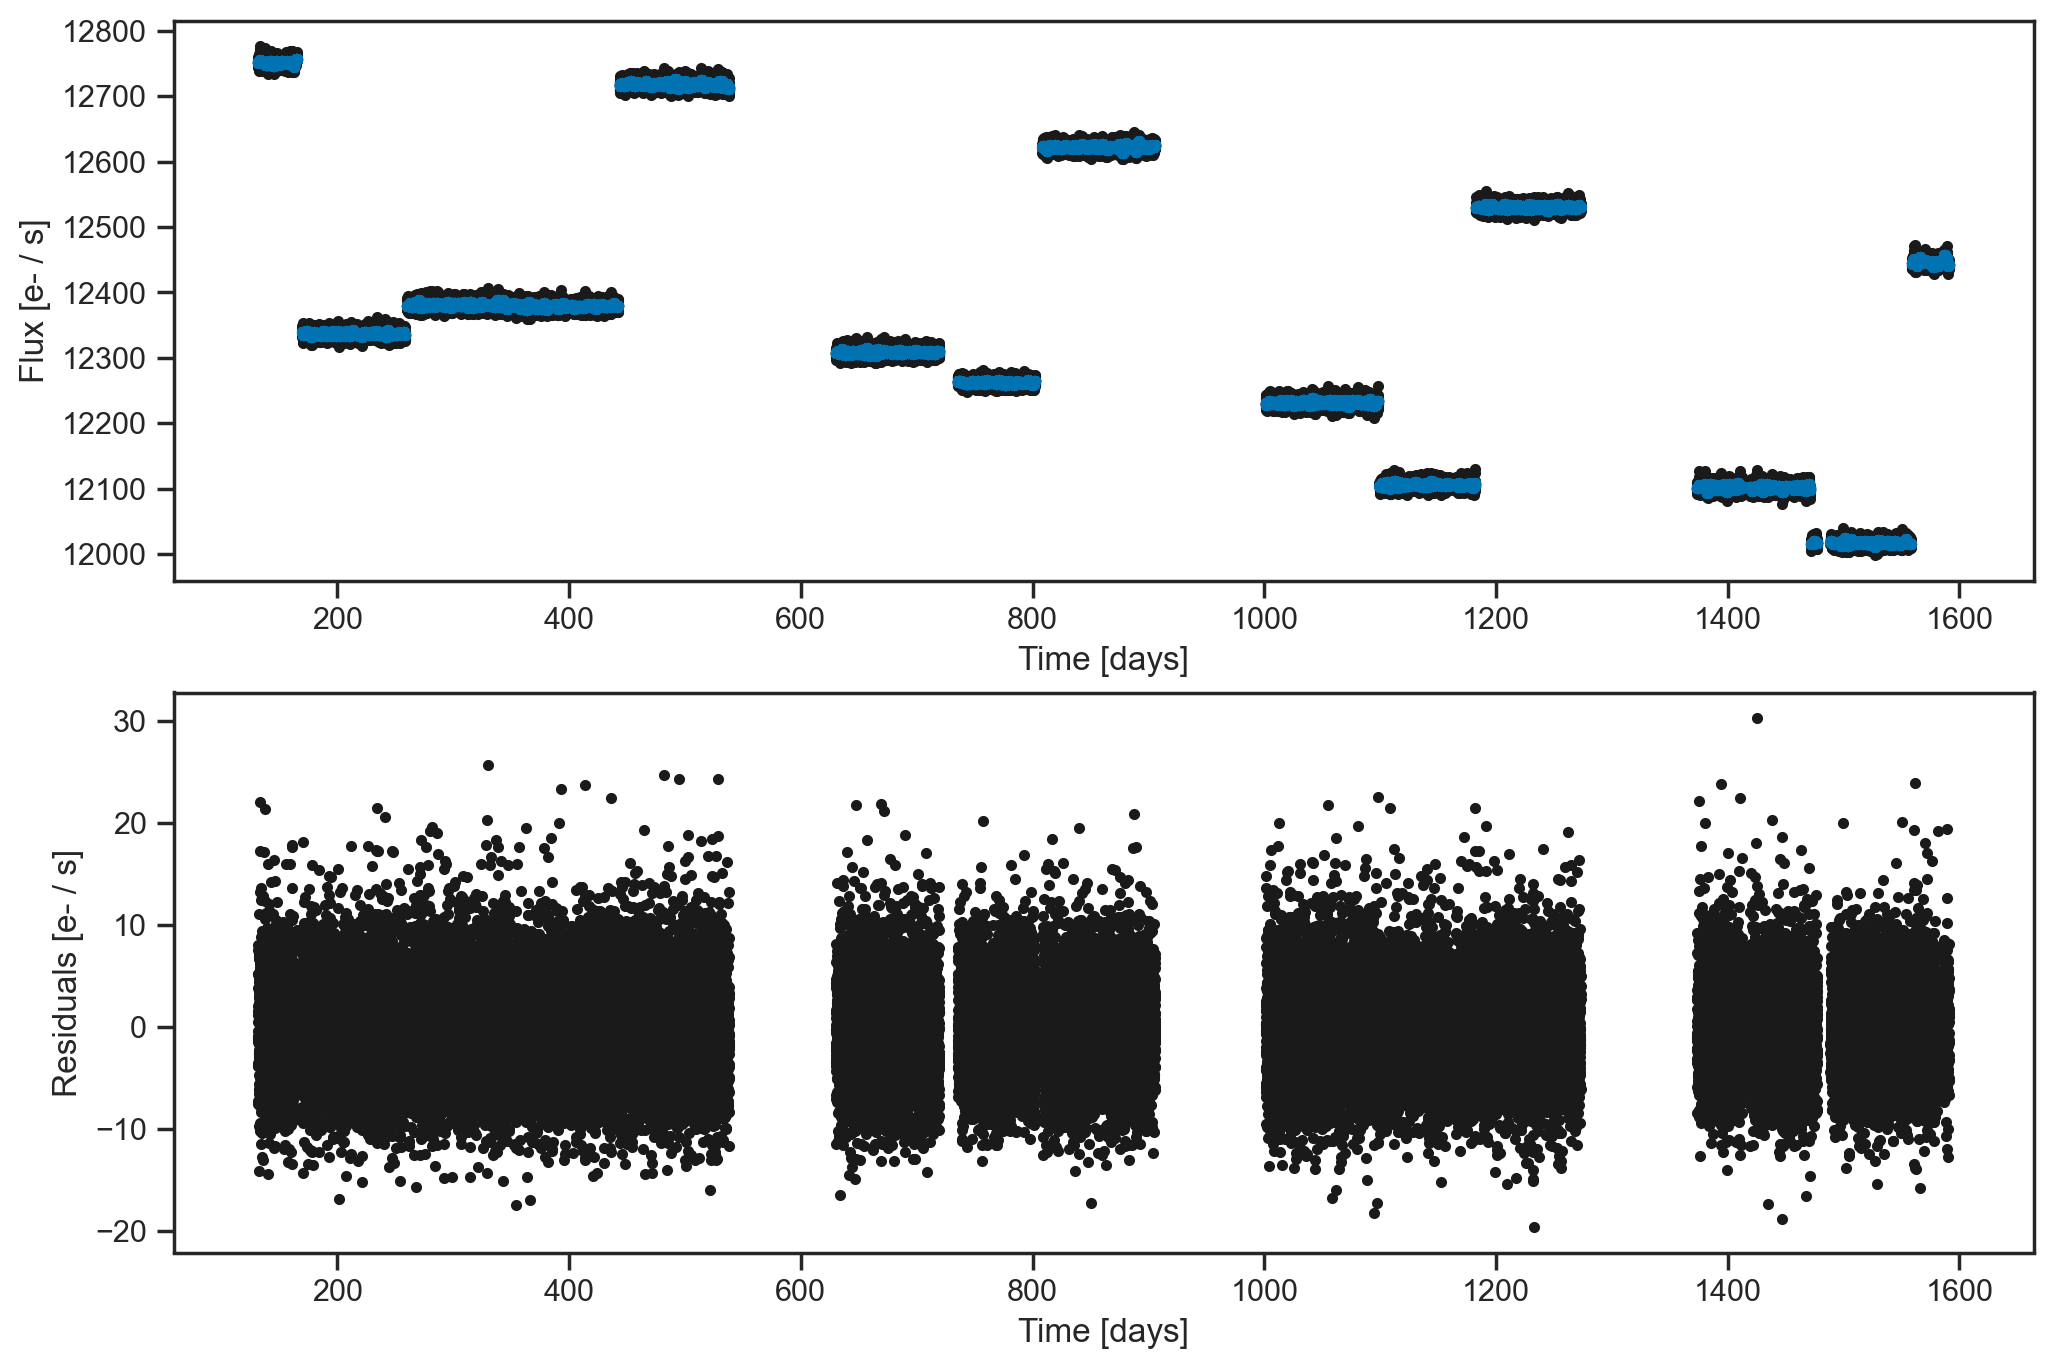

In [128]:
fig, subplots = plt.subplots(2, 1, figsize=(12, 8))

f = trace.posterior.gp_mean_model
fm = f.median(dim=['chain', 'draw']).values

subplots[0].plot(times, fluxes, '.k')
subplots[0].plot(times, fm, '.')
subplots[0].set_xlabel('Time [days]')
subplots[0].set_ylabel('Flux [e- / s]')

subplots[1].plot(times, fluxes - fm, '.k')
subplots[1].set_xlabel('Time [days]')
subplots[1].set_ylabel('Residuals [e- / s]')

Text(0, 0.5, '$f / \\mathrm{e- / s}$')

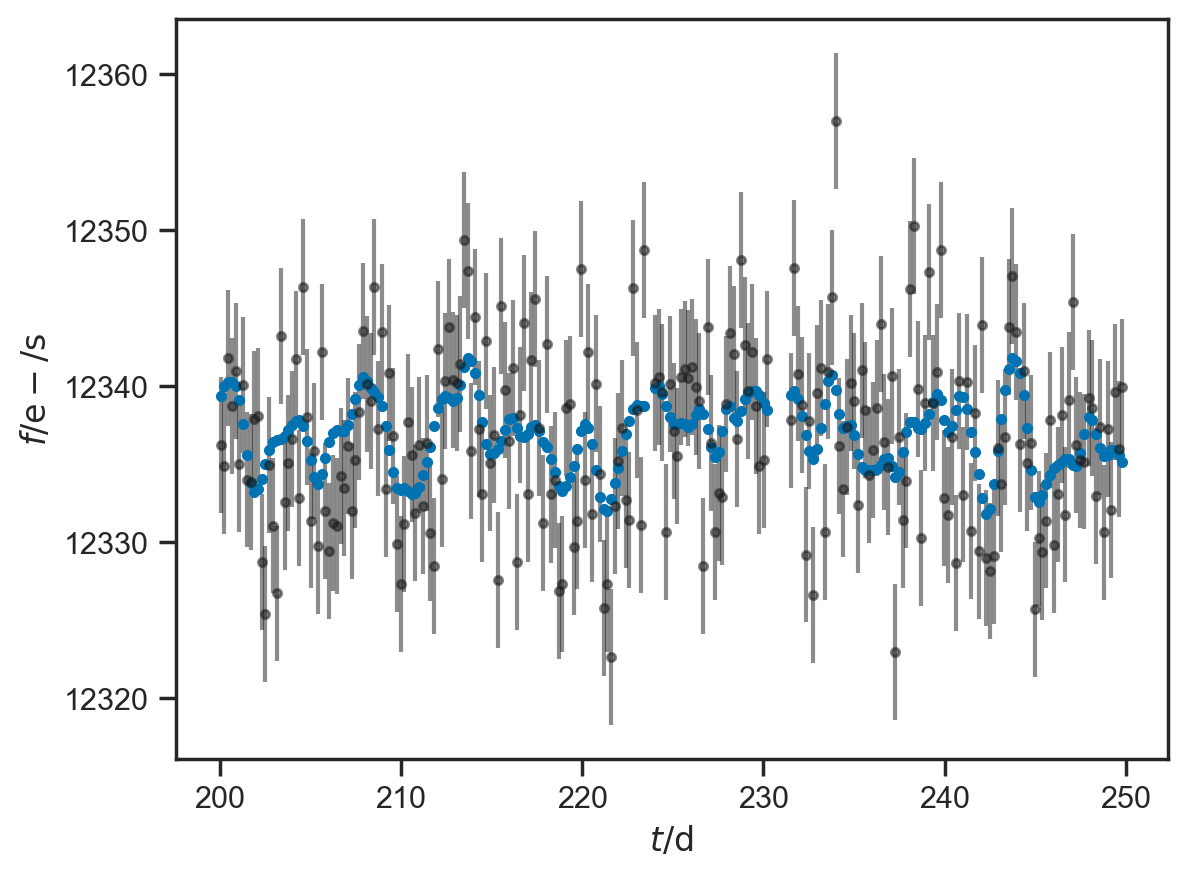

In [147]:
t = 10 # Thin for the plot

sel = np.abs(times[::thin_data][::t]-225) < 25
plt.errorbar(times[::thin_data][::t][sel], fluxes[::thin_data][::t][sel], yerr=flux_errs[::thin_data][::t][sel], fmt='.', alpha=0.5, color='k')
plt.plot(times[::thin_data][::t][sel], trace.posterior['gp_mean_model'].mean(dim=('chain', 'draw')).values.flatten()[::t][sel], '.')
plt.xlabel(r'$t / \mathrm{d}$')
plt.ylabel(r'$f / \mathrm{e- / s}$')

The PSD peaks pretty close to the best-fit location from the literature:

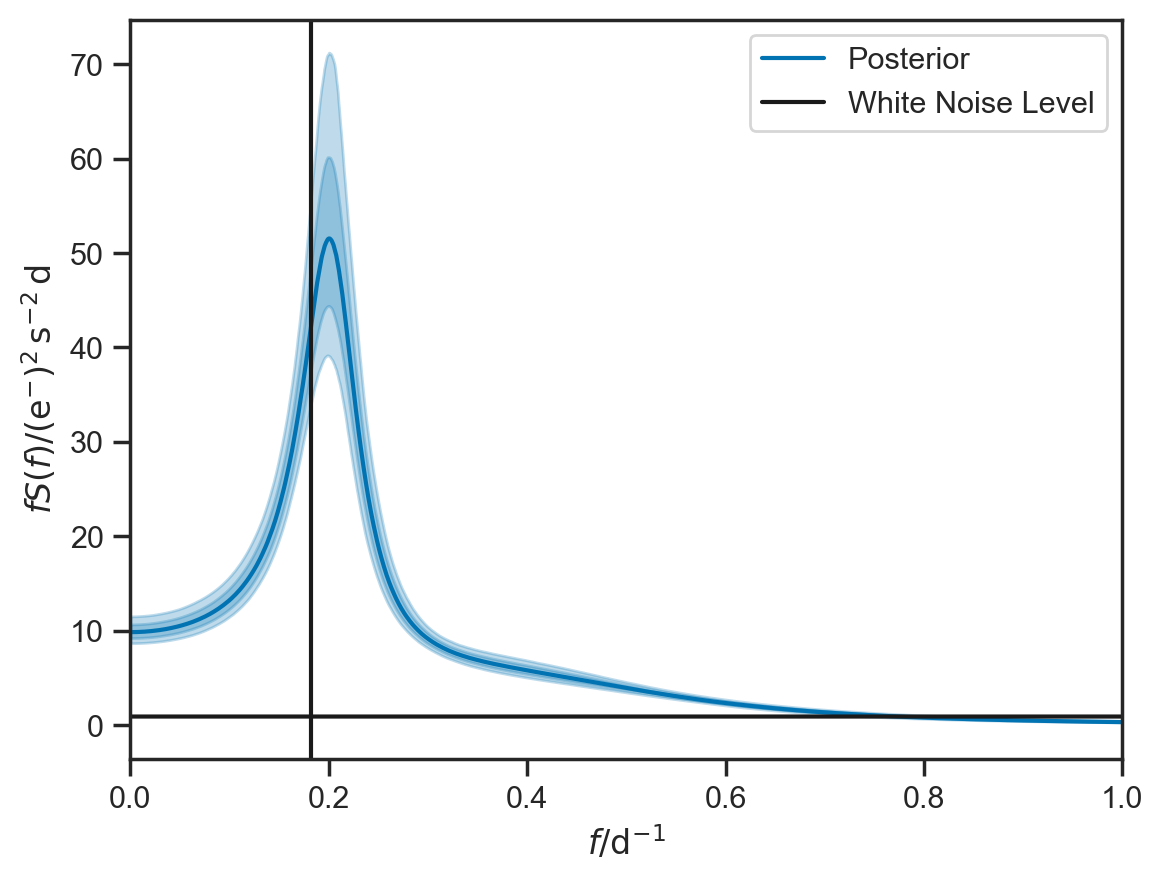

In [145]:
f = trace.posterior.frequencies.values.flatten()
l, = plt.plot(f, trace.posterior.psd.median(dim=('chain', 'draw')).values.flatten(), label='Posterior')
plt.fill_between(f, trace.posterior.psd.quantile(0.84, dim=('chain', 'draw')).values.flatten(), trace.posterior.psd.quantile(0.16, dim=('chain', 'draw')).values.flatten(), alpha=0.25, color=l.get_color())
plt.fill_between(f, trace.posterior.psd.quantile(0.975, dim=('chain', 'draw')).values.flatten(), trace.posterior.psd.quantile(0.025, dim=('chain', 'draw')).values.flatten(), alpha=0.25, color=l.get_color())
plt.plot(f, np.ones_like(f)*(white_noise_variance/fny)*trace.posterior.err_scale.mean().values[()]**2, 'k', label='White Noise Level')
plt.xlabel(r'$f / \mathrm{d}^{-1}$')
plt.ylabel(r'$f S(f) / \left( \mathrm{e}^{-} \right)^2 \, \mathrm{s}^{-2} \, \mathrm{d}$')
plt.legend()

plt.xlim(0,1)

plt.axvline(f_best, color='k')

Text(0.5, 0, '$f / \\mathrm{d}^{-1}$')

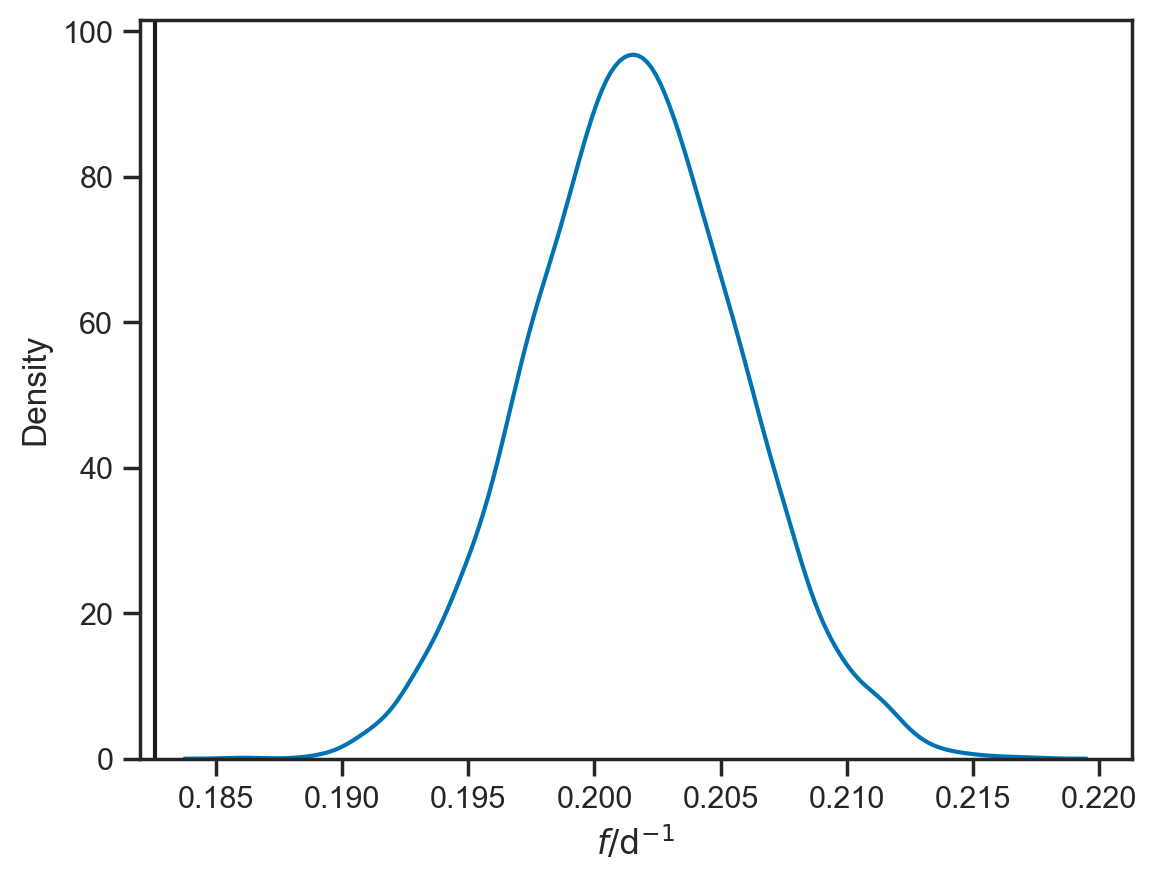

In [101]:
sns.kdeplot(trace.posterior['f0'].values.flatten())
plt.axvline(f_best, color='k')
plt.xlabel(r'$f / \mathrm{d}^{-1}$')

Text(0.5, 1.0, '$P = {4.96}^{+0.10}_{-0.10} \\, \\mathrm{d}$')

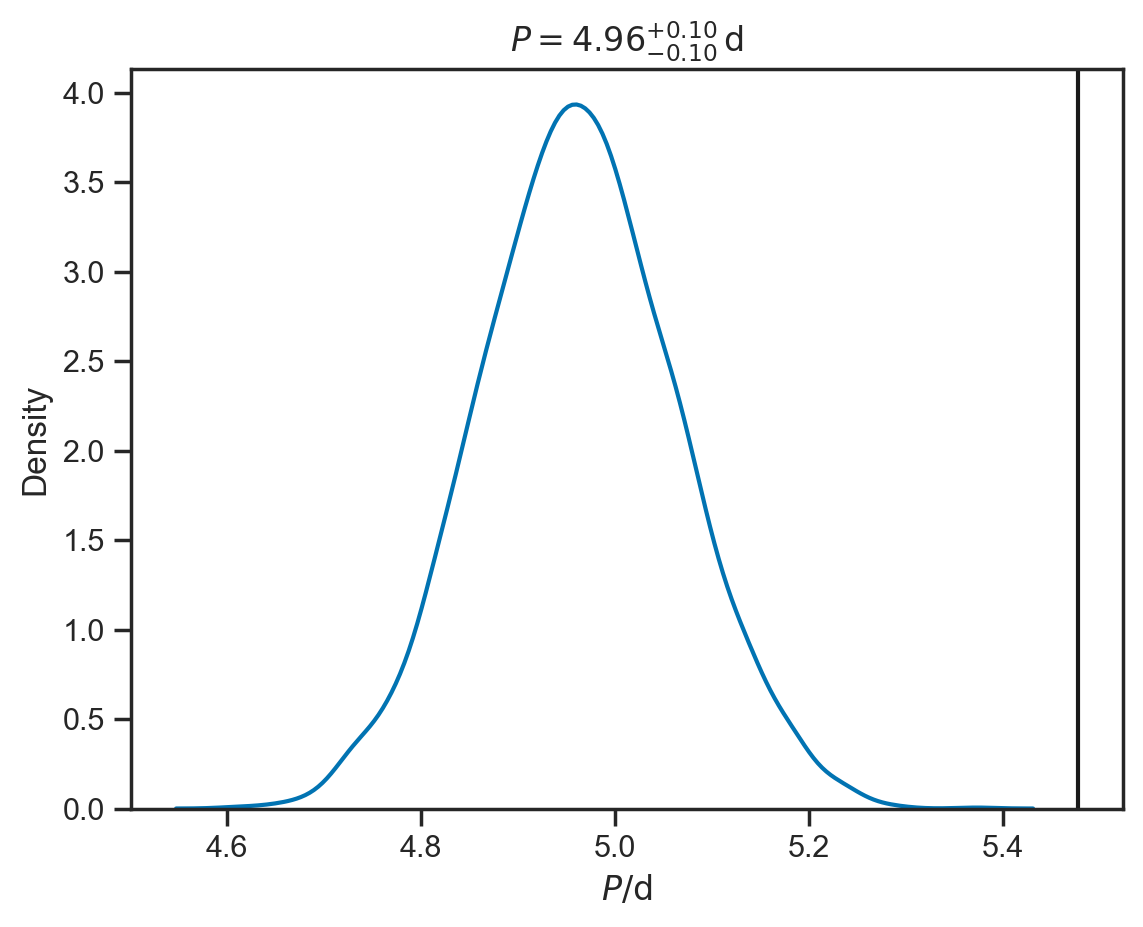

In [102]:
Ps = trace.posterior.period.values.flatten()
m, l, h = np.quantile(Ps, [0.5, 0.16, 0.84])


sns.kdeplot(Ps)
plt.axvline(1/f_best, color='k')
plt.xlabel(r'$P / \mathrm{d}$')
plt.title(r'$P = {{{:.2f}}}^{{+{:.2f}}}_{{-{:.2f}}} \, \mathrm{{d}}$'.format(m, h-m, m-l))